In [31]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tarfile
import urllib.request
from pathlib import Path

# Case Study
* **Aim**: To predict the median housing price in any district (given all the other metrics) by building a model using California census data.

## 1. Look at the big picture and frame the problem

1) Determine the business objective.
<br>

2) Review the current solution (if any), which will give us a reference for performance, as well as insights on how to solve the problem.
<br>

3) Deterimine which model to use.
    - Supervised ML: data were labeled
    - Regression task: to predict a value
        - Multiple regression: use multiple features 
        - Univariate regression: predict a single value
<br>

4) Select a performance measure
    - **Root mean squared error (RMSE)**: generally the preferred performance measure for regression problems
    <br>
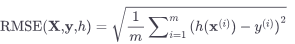
    - **Mean absolute error (MAE)**: more robust to outliers
    <br>
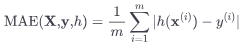
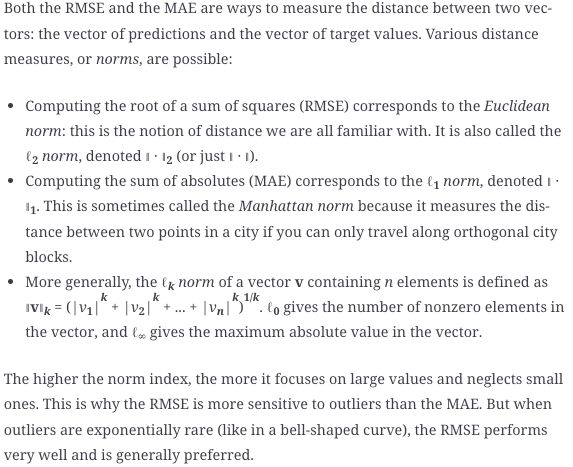
<br>

5) Check the assumptions
    - If downstream pipeline requires categorical variable input, we need to use classifcation model.

*Data pipeline: a sequence of data processing components.*

## 2. Get the Data
### 2.1 Take a Quick Look at the Data Structure

In [2]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

In [5]:
print(housing_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [7]:
print(housing_full.head(6))
print(housing_full.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [6]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [14]:
housing_full['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
housing_full['housing_median_age'].quantile([0.25, 0.5, 0.75])

0.25    18.0
0.50    29.0
0.75    37.0
Name: housing_median_age, dtype: float64

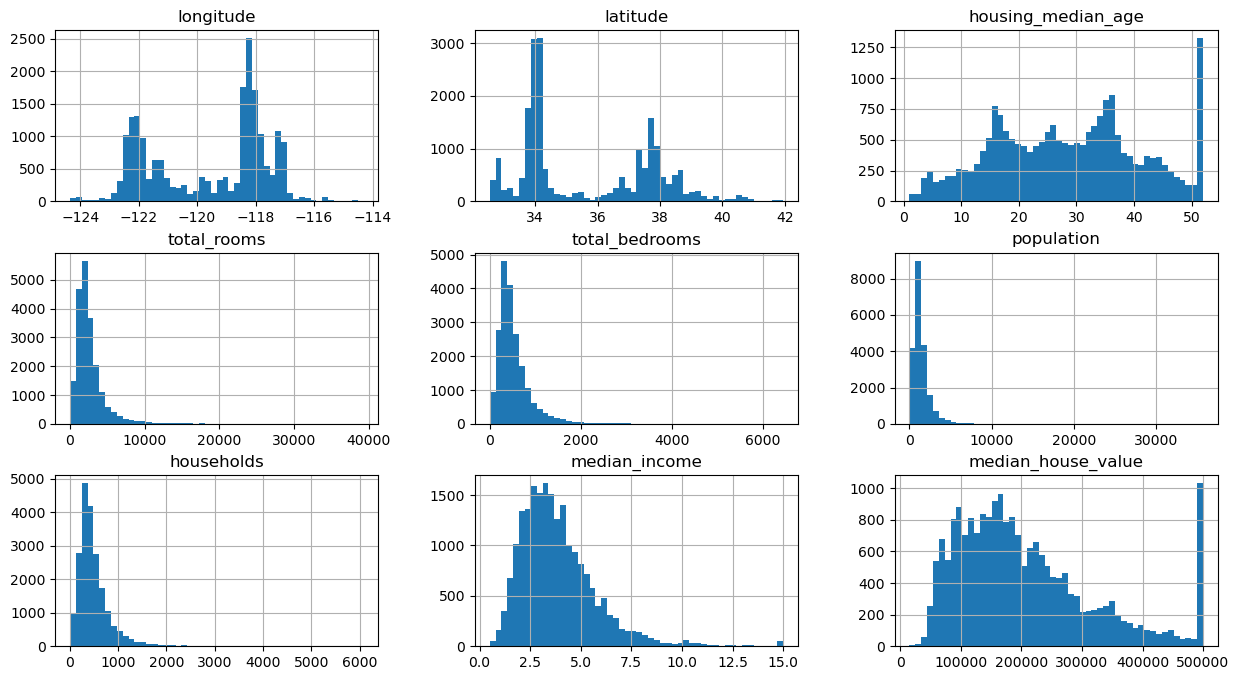

In [28]:
housing_full.hist(bins=50, figsize = (15, 8))
plt.show()
# plt.close('all') # Close all open figures to avoid memory issues when running this cell multiple times.

From the histogram, we can see that the `housing_median_age` and `median_house_value` were capped. The latter may be a problem since it is our target attribute. We need to check with the client team. If they need precise predictions even beyond 500,000, we can
- Collect proper labels for the districts whose labels were capped
- Remove those districts from the training and test set.

### 2.2 Create a Test Set
We need to create a test set, put it aside (never look at it), before look at the data any further. This is to avoid ***data snooping bias***, as the generalization error estimated from the test set can be underestimated if we select the ML model based on the test data. Typically, the test set comprises 20% of the data.

`np.random.default_rng(seed = x)` is Okay, but it will break the next time the dataset has been updated (e.g., more observations). To have a stable train/test split even after updating the dataset, a common solution is to use each instance's identifier to decide whether it should go in the test set (assuming instances have unique and immutable identifiers).

In [33]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [34]:
housing_with_id = housing_full.reset_index()  # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

## 3. Explore and Visualize the Data to Gain Insights

## 4. Prepare the Data for ML Algorithms